In [2]:
!pip install wordcloud



   ---------------------------------------- 0.0/301.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/301.2 kB ? eta -:--:--
   - -------------------------------------- 10.2/301.2 kB ? eta -:--:--
   --- ----------------------------------- 30.7/301.2 kB 325.1 kB/s eta 0:00:01
   ----- --------------------------------- 41.0/301.2 kB 326.8 kB/s eta 0:00:01
   --------------- ---------------------- 122.9/301.2 kB 717.5 kB/s eta 0:00:01
   ------------------------ ------------- 194.6/301.2 kB 903.5 kB/s eta 0:00:01
   ----------------------------------- ---- 266.2/301.2 kB 1.0 MB/s eta 0:00:01
   ---------------------------------------- 301.2/301.2 kB 1.1 MB/s eta 0:00:00


ERROR: Could not install packages due to an OSError: [WinError 2] The system cannot find the file specified: 'C:\\Python312\\Scripts\\wordcloud_cli.exe' -> 'C:\\Python312\\Scripts\\wordcloud_cli.exe.deleteme'


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


In [17]:
df=pd.read_csv("IPL_2023_CLEANED.csv")
df.head(500)

,player,base_price,type,cost_in_₹_(cr.),cost_in_$_(000),2022_squad,team,base_price_in_₹,base_price_in_$,base_price_status,base_price_status_$
0,Shivam Mavi,4000000,BOWLER,6.0,720.0,KKR,Gujarat Titans,0.0,0.0,Not Declared,Not Declared
1,Joshua Little,5000000,BOWLER,4.4,528.0,Not in Squad,Gujarat Titans,0.0,0.0,Not Declared,Not Declared
2,Kane Williamson,20000000,BATSMAN,2.0,240.0,SRH,Gujarat Titans,0.0,0.0,Not Declared,Not Declared
3,K.S. Bharat,2000000,WICKETKEEPER,1.2,144.0,DC,Gujarat Titans,0.0,0.0,Not Declared,Not Declared
4,Mohit Sharma,5000000,BOWLER,0.5,60.0,Not in Squad,Gujarat Titans,0.0,0.0,Not Declared,Not Declared
...,...,...,...,...,...,...,...,...,...,...,...
495,Rajesh Mohanty,Unknown,BOWLER,NaN,NaN,Not in Squad,Unsold,2000000.0,24000.0,Declared,Declared
496,Ravi Sharma,Unknown,BOWLER,NaN,NaN,Not in Squad,Unsold,2000000.0,24000.0,Declared,Declared
497,Vikash Singh,Unknown,BOWLER,NaN,NaN,Not in Squad,Unsold,2000000.0,24000.0,Declared,Declared
498,Ruben Trumpelmann,Unknown,BOWLER,NaN,NaN,Not in Squad,Unsold,2000000.0,24000.0,Declared,Declared


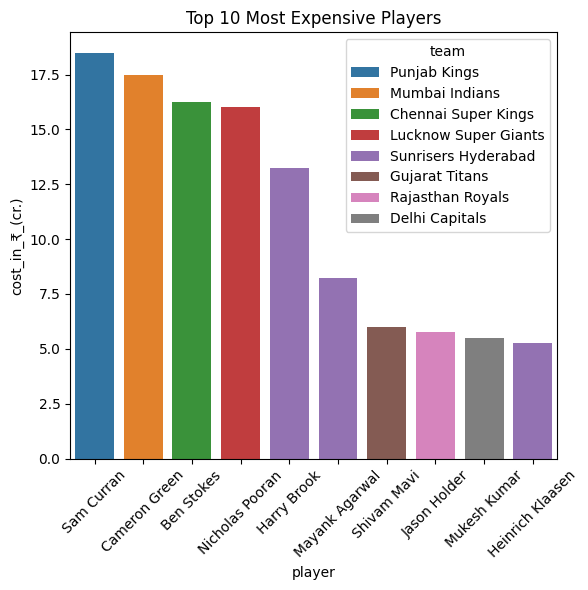

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

top_10 = df.sort_values(by="cost_in_₹_(cr.)", ascending=False).head(10)
plt.figure(figsize=(6,6))
sns.barplot(data=top_10, x="player", y="cost_in_₹_(cr.)", hue="team")
plt.xticks(rotation=45)
plt.title("Top 10 Most Expensive Players")
plt.tight_layout()
plt.show()


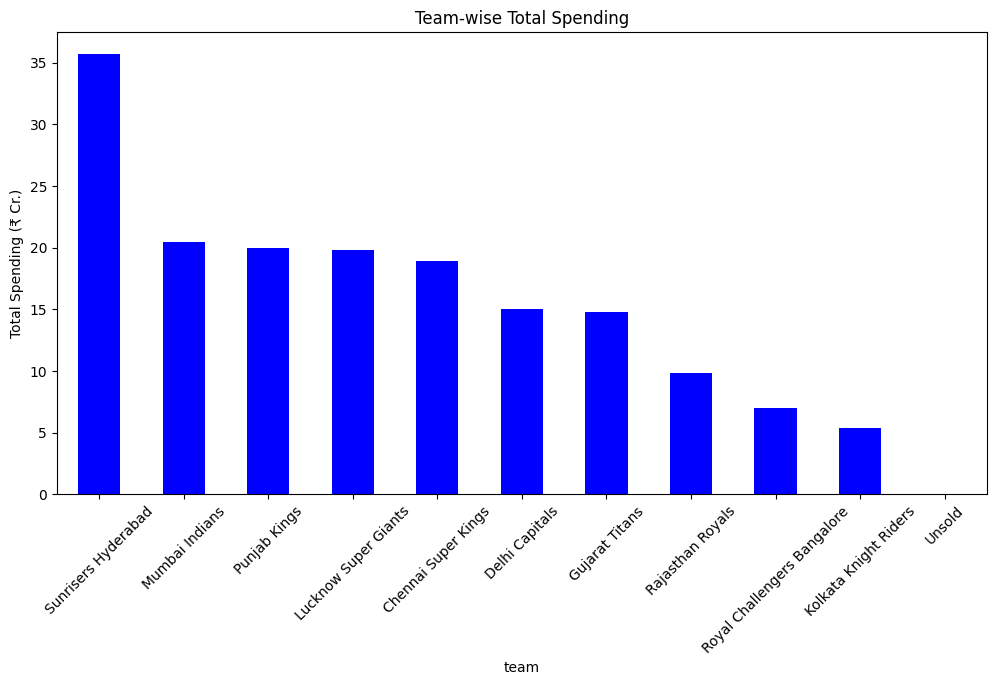

In [19]:
team_spending = df.groupby("team")["cost_in_₹_(cr.)"].sum().sort_values(ascending=False)
plt.figure(figsize=(12,6))
team_spending.plot(kind="bar", color="blue")
plt.ylabel("Total Spending (₹ Cr.)")
plt.title("Team-wise Total Spending")
plt.xticks(rotation=45)
plt.show()



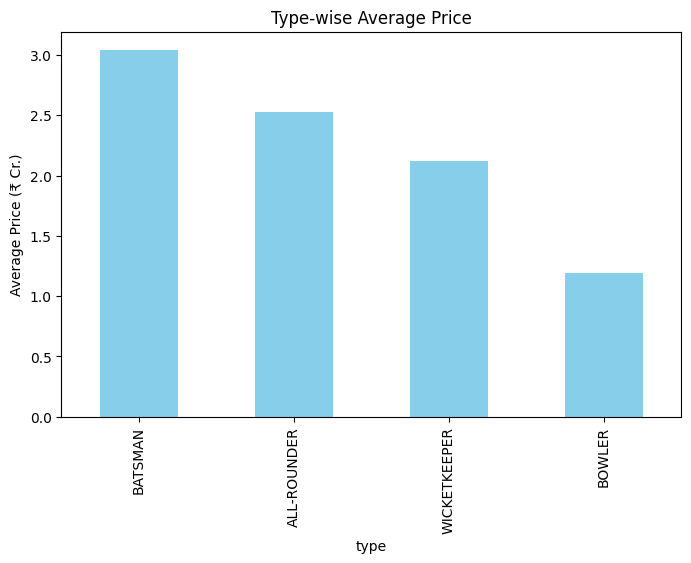

In [20]:
type_avg = df.groupby("type")["cost_in_₹_(cr.)"].mean().sort_values(ascending=False)
plt.figure(figsize=(8,5))
type_avg.plot(kind="bar", color="skyblue")
plt.ylabel("Average Price (₹ Cr.)")
plt.title("Type-wise Average Price")
plt.show()


In [21]:
unsold = df[df["cost_in_₹_(cr.)"].isna()]
print("Total Unsold Players:", len(unsold))
unsold[["player", "base_price", "type"]]




Total Unsold Players: 488


,player,base_price,type
7,Rahul Tewatia,Retained,ALL-ROUNDER
8,Pradeep Sangwan,Retained,ALL-ROUNDER
9,Rashid Khan,Retained,BOWLER
10,R. Sai Kishore,Retained,BOWLER
11,Yash Dayal,Retained,BOWLER
...,...,...,...
563,Dhruv Patel,Unknown,ALL-ROUNDER
564,Jack Prestwidge,Unknown,ALL-ROUNDER
565,Aditya Sarvate,Unknown,ALL-ROUNDER
566,Sagar Solanki,Unknown,ALL-ROUNDER


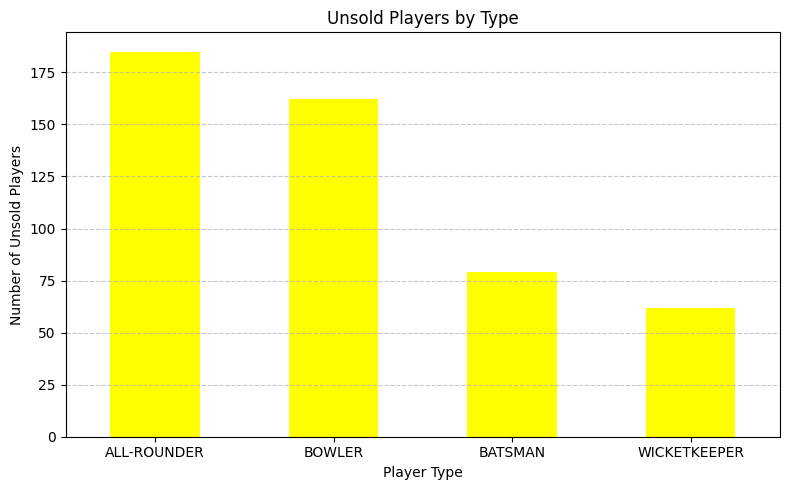

In [22]:
unsold_by_type = unsold["type"].value_counts()

plt.figure(figsize=(8, 5))
unsold_by_type.plot(kind="bar", color="yellow")
plt.title("Unsold Players by Type")
plt.xlabel("Player Type")
plt.ylabel("Number of Unsold Players")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

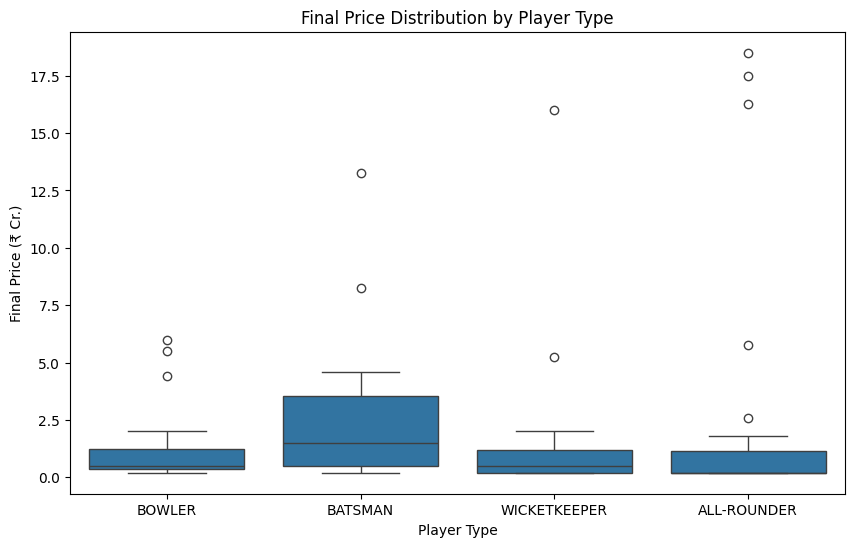

In [23]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="type", y="cost_in_₹_(cr.)")
plt.title("Final Price Distribution by Player Type")
plt.xlabel("Player Type")
plt.ylabel("Final Price (₹ Cr.)")
plt.show()



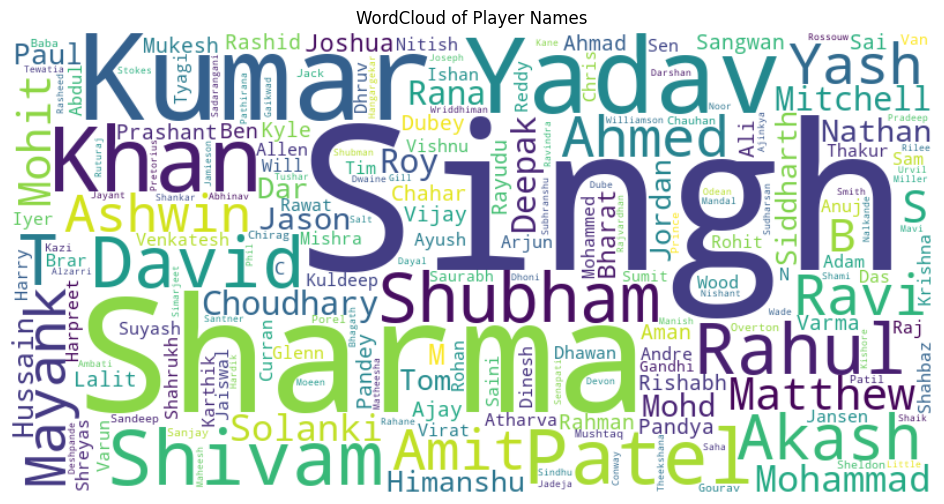

In [24]:
text = " ".join(df["player"].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud of Player Names")
plt.show()

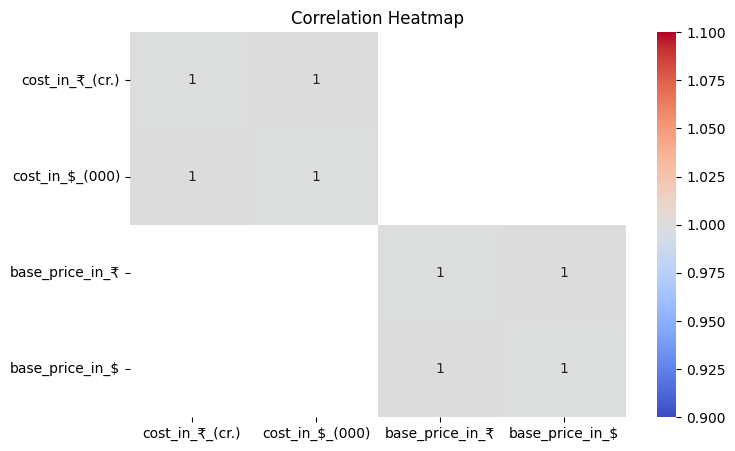

In [25]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [12]:
print(df.columns)  # nationality check krrhe the


Index(['player', 'base_price', 'type', 'cost_in_₹_(cr.)', 'cost_in_$_(000)',
       '2022_squad', 'team', 'base_price_in_₹', 'base_price_in_$',
       'base_price_status', 'base_price_status_$'],
      dtype='object')


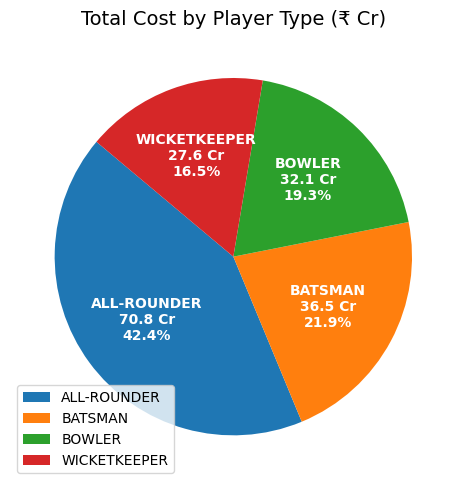

In [31]:
import matplotlib.pyplot as plt

# Aggregate data
grouped = df.groupby("type")["cost_in_₹_(cr.)"].sum()

# Prepare labels with both name and percentage
labels = [f"{label}\n{value:.1f} Cr" for label, value in zip(grouped.index, grouped.values)]

# Plot with custom labels inside
plt.figure(figsize=(5, 5))
wedges, texts, autotexts = plt.pie(
    grouped, 
    labels=None,                     # No default labels
    autopct='%1.1f%%',               # Show percentage inside
    startangle=140, 
    textprops={'color': 'white', 'weight': 'bold'}
)

# Manually set inside labels
for i, a in enumerate(autotexts):
    a.set_text(f"{labels[i]}\n{a.get_text()}")  # Add label + percentage

plt.title("Total Cost by Player Type (₹ Cr)", fontsize=14)
plt.legend(grouped.index, loc="best")  # Optional: separate legend
plt.tight_layout()
plt.show()


In [29]:
df.groupby("team")["cost_in_₹_(cr.)"].sum().sort_values(ascending=False)



team
Sunrisers Hyderabad            35.70
Mumbai Indians                 20.50
Punjab Kings                   20.00
Lucknow Super Giants           19.80
Chennai Super Kings            18.95
Delhi Capitals                 15.00
Gujarat Titans                 14.80
Rajasthan Royals                9.85
Royal Challengers Bangalore     7.00
Kolkata Knight Riders           5.40
Unsold                          0.00
Name: cost_in_₹_(cr.), dtype: float64